In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\Hp\Downloads\NayShin_Code\QVI_purchase_behaviour.csv")
df2 = pd.read_csv(r"C:\Users\Hp\Downloads\NayShin_Code\QVI_transaction_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [4]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [5]:
df['LIFESTAGE'].value_counts()

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

In [6]:
df2['PROD_NAME'].value_counts()

PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
                                            ... 
RRD Pc Sea Salt     165g                    1431
Woolworths Medium   Salsa 300g              1430
NCC Sour Cream &    Garden Chives 175g      1419
French Fries Potato Chips 175g              1418
WW Crinkle Cut      Original 175g           1410
Name: count, Length: 114, dtype: int64

In [7]:
df2

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [8]:
df2['PROD_QTY'].value_counts()

PROD_QTY
2      236039
1       27518
5         450
3         430
4         397
200         2
Name: count, dtype: int64

In [9]:
df2['TOT_SALES'].value_counts()

TOT_SALES
9.2      22821
7.4      22513
6.0      20798
7.6      20212
8.8      19900
         ...  
9.3          3
6.9          3
12.4         2
650.0        2
11.2         2
Name: count, Length: 112, dtype: int64

In [10]:
df2['DATE']=pd.to_datetime(df2['DATE'], unit='D', origin='1900-01-01')

In [11]:
df2.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2019-01-01 00:52:12.879215616,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-03 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-10-02 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2019-01-01 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-04-02 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-07-02 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


In [12]:
df2.dropna(subset=['TXN_ID','TOT_SALES'], inplace=True)

In [13]:
print(f"Null:{len(df2)}")

Null:264836


In [ ]:
duplicates_count= df2.duplicated(subset=['TXN_ID'])
print([duplicates_count.sum() ])


[np.int64(1709)]


In [15]:
df2.drop_duplicates(subset=['TXN_ID'], keep ='first', inplace=True)
print(f"After removing duplicate:{len(df2)}")

After removing duplicate:263127


In [16]:
initial_rows = len(df2)
df2=df2.query('TOT_SALES>0 and PROD_QTY>0')
removed_rows = initial_rows - len(df2)
print({removed_rows})


{0}


In [17]:
import numpy as np
def Capping_outliers(df2,col_name,factor=1.5):
    Q1 = df2[col_name].quantile(0.25)
    Q3 = df2[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_upper= df2[df2[col_name] > upper_bound]
    outlier_lower= df2[df2[col_name] < lower_bound]
    print(outlier_upper)
    print(outlier_lower)

    df2[col_name] =np.where( df2[col_name]> upper_bound, upper_bound, df2[col_name])
    df2[col_name] =np.where (df2[col_name]< lower_bound, lower_bound, df2[col_name])
    return df2

In [18]:
numerical_cols = ['PROD_QTY','TOT_SALES']
for col in numerical_cols:
    df2 = Capping_outliers(df2, col)
    print(df2[numerical_cols].describe())


             DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
1      2019-05-16          1            1307     348        66   
3      2018-08-19          2            2373     974        69   
4      2018-08-20          2            2426    1038       108   
11     2018-08-22          8            8294    8221       114   
16     2018-08-20         20           20418   17413        94   
...           ...        ...             ...     ...       ...   
258745 2019-05-21        220          220338  219884        98   
258759 2019-05-16        238          238169  242560        44   
258770 2019-05-20        248          248246  250503        80   
258782 2018-08-17        259          259174  258569        92   
258788 2019-05-16        264          264149  262909        25   

                                       PROD_NAME  PROD_QTY  TOT_SALES  
1                       CCs Nacho Cheese    175g         3        6.3  
3         Smiths Chip Thinly  S/Cream&Onion 175g         5     

       PROD_QTY      TOT_SALES
count  263127.0  263127.000000
mean        2.0       7.304008
std         0.0       3.087069
min         2.0       1.500000
25%         2.0       5.400000
50%         2.0       7.400000
75%         2.0       9.200000
max         2.0     650.000000
             DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
3      2018-08-19          2            2373     974        69   
11     2018-08-22          8            8294    8221       114   
56     2019-05-18         74           74336   73182        84   
72     2018-08-21         96           96203   96025         7   
100    2019-05-22        130          130108  134125         2   
...           ...        ...             ...     ...       ...   
258715 2018-08-18        194          194381  194835       102   
258721 2018-08-17        200          200248  199694         3   
258726 2018-08-22        203          203253  203360        28   
258729 2019-05-18        208          208205  207318        3

In [19]:
df2.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,263127,263127.000000,2.631270e+05,2.631270e+05,263127.000000,263127.0,263127.000000
mean,2019-01-01 00:40:56.778666240,135.080672,1.355521e+05,1.351594e+05,56.579268,2.0,7.288657
min,2018-07-03 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,2.0,1.500000
25%,2018-10-02 00:00:00,70.000000,7.001800e+04,6.758450e+04,28.000000,2.0,5.400000
50%,2019-01-01 00:00:00,130.000000,1.303580e+05,1.351430e+05,56.000000,2.0,7.400000
75%,2019-04-02 00:00:00,203.000000,2.031010e+05,2.027255e+05,85.000000,2.0,9.200000
max,2019-07-02 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,2.0,14.900000
std,NaN,76.799192,8.061834e+04,7.814901e+04,32.824478,0.0,2.479924


In [20]:
df2.value_counts()

DATE        STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  PROD_NAME                                 PROD_QTY  TOT_SALES
2019-07-02  272        272096          269769  49        Infuzions SourCream&Herbs Veg Strws 110g  2.0       7.6          1
2018-07-03  1          1233            266     110       WW Original Corn    Chips 200g            2.0       1.9          1
                       1482            563     8         Smiths Crinkle Cut  Chips Original 170g   2.0       2.9          1
            2          2117            712     73        Smiths Crinkle Cut  Salt & Vinegar 170g   2.0       2.9          1
                       2283            895     108       Kettle Tortilla ChpsHny&Jlpno Chili 150g  2.0       9.2          1
                                                                                                                         ..
            5          5109            4994    60        Kettle Tortilla ChpsFeta&Garlic 150g      2.0       9.2          1
             

In [21]:
df2['PROD_NAME']=df2['PROD_NAME'].astype(str).str.strip()

In [22]:
df2['PROD_NAME']=df2['PROD_NAME'].str.lower()

In [23]:
df2.value_counts()

DATE        STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  PROD_NAME                                 PROD_QTY  TOT_SALES
2019-07-02  272        272096          269769  49        infuzions sourcream&herbs veg strws 110g  2.0       7.6          1
2018-07-03  1          1233            266     110       ww original corn    chips 200g            2.0       1.9          1
                       1482            563     8         smiths crinkle cut  chips original 170g   2.0       2.9          1
            2          2117            712     73        smiths crinkle cut  salt & vinegar 170g   2.0       2.9          1
                       2283            895     108       kettle tortilla chpshny&jlpno chili 150g  2.0       9.2          1
                                                                                                                         ..
            5          5109            4994    60        kettle tortilla chpsfeta&garlic 150g      2.0       9.2          1
             

In [24]:
df2.to_csv(r"C:\Users\Hp\Downloads\NayShin_Code\QVI_transaction_data_cleaned.csv", index=False)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [26]:
df.duplicated(subset='LYLTY_CARD_NBR').sum()

np.int64(0)

In [27]:
df3=df.merge(df2, on='LYLTY_CARD_NBR')

In [28]:
df2.groupby('PROD_NBR')['PROD_NAME'].nunique().sort_values(ascending=False)

PROD_NBR
1      1
2      1
3      1
4      1
5      1
      ..
110    1
111    1
112    1
113    1
114    1
Name: PROD_NAME, Length: 114, dtype: int64

In [29]:
df3

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,1000,YOUNG SINGLES/COUPLES,Premium,2018-10-19,1,1,5,natural chip compny seasalt175g,2.0,6.0
1,1002,YOUNG SINGLES/COUPLES,Mainstream,2018-09-18,1,2,58,red rock deli chikn&garlic aioli 150g,2.0,2.7
2,1003,YOUNG FAMILIES,Budget,2019-03-09,1,3,52,grain waves sour cream&chives 210g,2.0,3.6
3,1003,YOUNG FAMILIES,Budget,2019-03-10,1,4,106,natural chipco hony soy chckn175g,2.0,3.0
4,1004,OLDER SINGLES/COUPLES,Mainstream,2018-11-04,1,5,96,ww original stacked chips 160g,2.0,1.9
...,...,...,...,...,...,...,...,...,...,...
263122,2370701,YOUNG FAMILIES,Mainstream,2018-12-10,88,240378,24,grain waves sweet chilli 210g,2.0,7.2
263123,2370751,YOUNG FAMILIES,Premium,2018-10-03,88,240394,60,kettle tortilla chpsfeta&garlic 150g,2.0,9.2
263124,2370961,OLDER FAMILIES,Budget,2018-10-26,88,240480,70,tyrrells crisps lightly salted 165g,2.0,8.4
263125,2370961,OLDER FAMILIES,Budget,2018-10-29,88,240481,65,old el paso salsa dip chnky tom ht300g,2.0,10.2


In [30]:
Total_sales_per_lifestage = df3.groupby('LIFESTAGE')['TOT_SALES'].sum()
display(Total_sales_per_lifestage)

LIFESTAGE
MIDAGE SINGLES/COUPLES    183279.05
NEW FAMILIES               50205.60
OLDER FAMILIES            348429.55
OLDER SINGLES/COUPLES     399310.45
RETIREES                  364084.75
YOUNG FAMILIES            313200.15
YOUNG SINGLES/COUPLES     259332.90
Name: TOT_SALES, dtype: float64

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

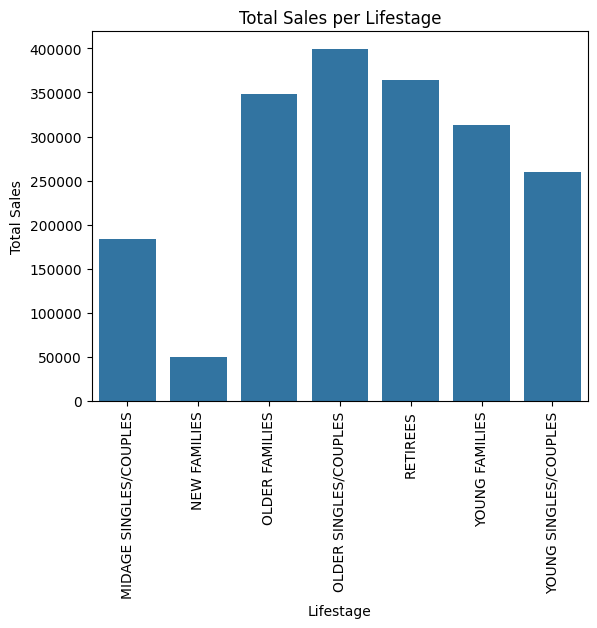

In [32]:
sns.barplot(x=Total_sales_per_lifestage.index, y=Total_sales_per_lifestage.values)
plt.title('Total Sales per Lifestage')
plt.xlabel('Lifestage') 
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.show()

The Bar chat comparing Total Sales Per Lifestage reveal that The Older Singles/Couples segment generates the highest sales and NEw Families segment generates the lowest sales.

In [33]:
Total_sales_per_premium = df3.groupby('PREMIUM_CUSTOMER')['TOT_SALES'].sum()
display(Total_sales_per_premium)

PREMIUM_CUSTOMER
Budget        670469.10
Mainstream    745247.55
Premium       502125.80
Name: TOT_SALES, dtype: float64

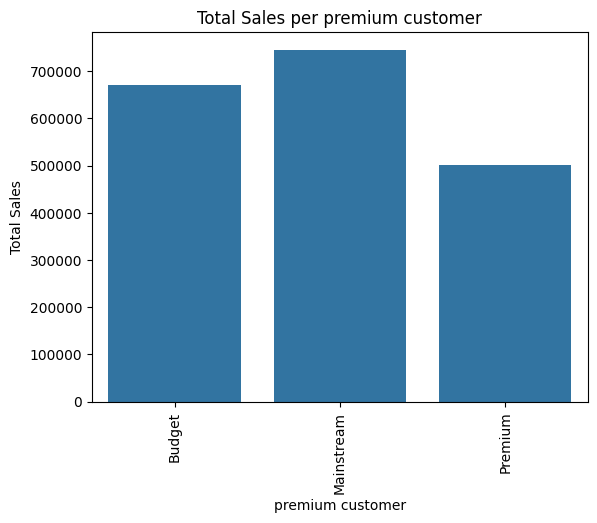

In [34]:
sns.barplot(x=Total_sales_per_premium.index, y=Total_sales_per_premium.values)
plt.title('Total Sales per premium customer')      
plt.xlabel('premium customer')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.show()

The bar chart is comparing about Total sales per premium customer reveal that the Mainstream segment generates the highest sales while the Premium segment generates the lowest sales.

In [35]:

Data1=df3.groupby(['LIFESTAGE','PREMIUM_CUSTOMER']).size().reset_index(name='counts')

In [36]:
Data1

,LIFESTAGE,PREMIUM_CUSTOMER,counts
0,MIDAGE SINGLES/COUPLES,Budget,4988
1,MIDAGE SINGLES/COUPLES,Mainstream,11801
2,MIDAGE SINGLES/COUPLES,Premium,8160
3,NEW FAMILIES,Budget,2991
4,NEW FAMILIES,Mainstream,2321
5,NEW FAMILIES,Premium,1584
6,OLDER FAMILIES,Budget,22935
7,OLDER FAMILIES,Mainstream,14113
8,OLDER FAMILIES,Premium,11078
9,OLDER SINGLES/COUPLES,Budget,18301


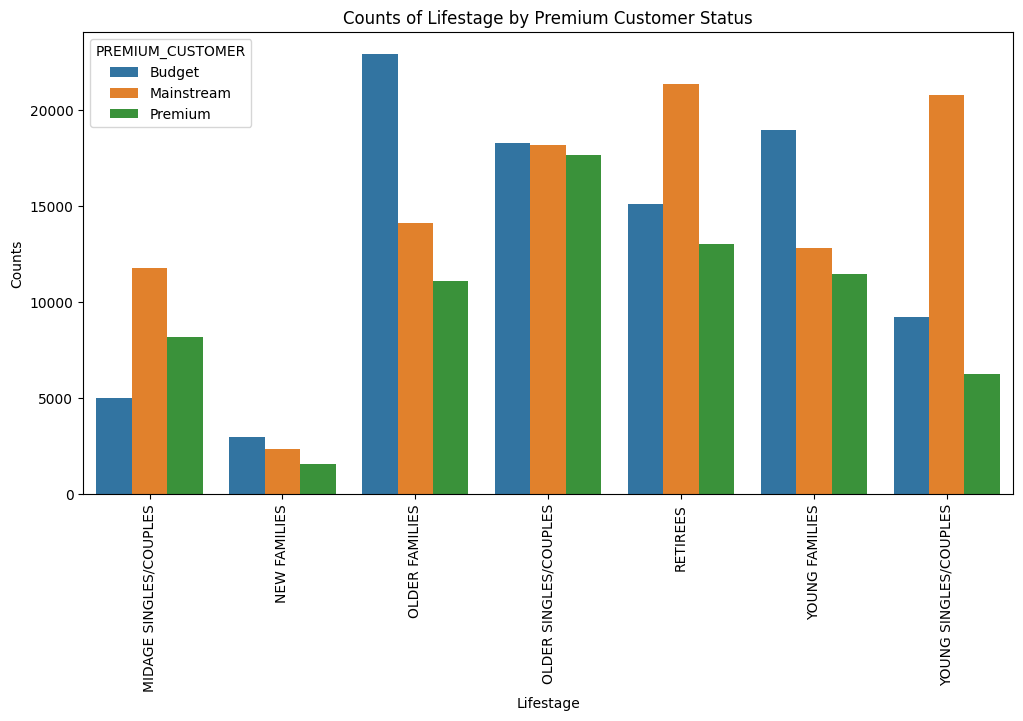

In [37]:
plt.figure(figsize=(12,6))
sns.barplot(data=Data1,x='LIFESTAGE',y='counts',hue='PREMIUM_CUSTOMER')
plt.title('Counts of Lifestage by Premium Customer Status')
plt.xlabel('Lifestage') 
plt.ylabel('Counts')
plt.xticks(rotation=90)
plt.show()

The Chart reveals about The Counts of Lifestage by Premium Customer Status,indicate "Older Families" segment reveals the highest counts overall while "New Families" indcates the lowest count overall across the three customer status categories.

In [38]:
df3['Packet_size']=df3['PROD_NAME'].str.extract(r'(\d+)(?=\D$)').astype(float)
display(df3['Packet_size'])


0         175.0
1         150.0
2         210.0
3         175.0
4         160.0
          ...  
263122    210.0
263123    150.0
263124    165.0
263125    300.0
263126    330.0
Name: Packet_size, Length: 263127, dtype: float64

In [39]:
avg_packet_size_by_customer_type = df3.groupby('LIFESTAGE')['Packet_size'].mean()
print(avg_packet_size_by_customer_type)

LIFESTAGE
MIDAGE SINGLES/COUPLES    183.337324
NEW FAMILIES              182.040265
OLDER FAMILIES            182.684259
OLDER SINGLES/COUPLES     183.048174
RETIREES                  183.301735
YOUNG FAMILIES            182.441866
YOUNG SINGLES/COUPLES     183.757730
Name: Packet_size, dtype: float64


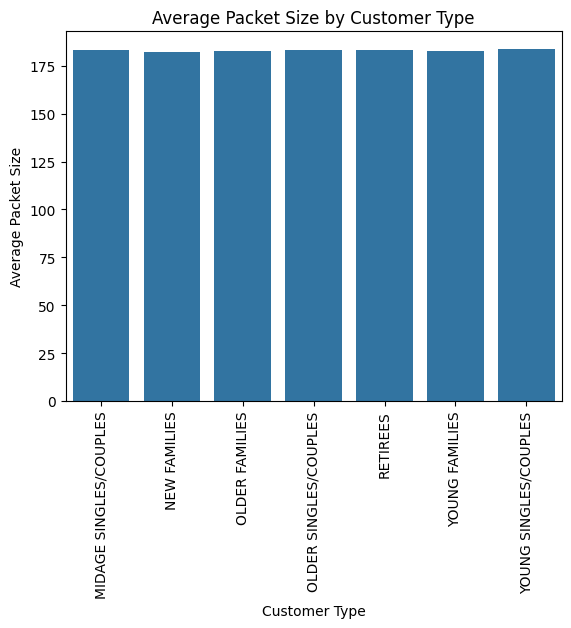

In [40]:
sns.barplot(x=avg_packet_size_by_customer_type.index, y=avg_packet_size_by_customer_type.values)
plt.title('Average Packet Size by Customer Type')       
plt.xlabel('Customer Type')
plt.ylabel('Average Packet Size')
plt.xticks(rotation=90)
plt.show()

In [41]:
df3

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,Packet_size
0,1000,YOUNG SINGLES/COUPLES,Premium,2018-10-19,1,1,5,natural chip compny seasalt175g,2.0,6.0,175.0
1,1002,YOUNG SINGLES/COUPLES,Mainstream,2018-09-18,1,2,58,red rock deli chikn&garlic aioli 150g,2.0,2.7,150.0
2,1003,YOUNG FAMILIES,Budget,2019-03-09,1,3,52,grain waves sour cream&chives 210g,2.0,3.6,210.0
3,1003,YOUNG FAMILIES,Budget,2019-03-10,1,4,106,natural chipco hony soy chckn175g,2.0,3.0,175.0
4,1004,OLDER SINGLES/COUPLES,Mainstream,2018-11-04,1,5,96,ww original stacked chips 160g,2.0,1.9,160.0
...,...,...,...,...,...,...,...,...,...,...,...
263122,2370701,YOUNG FAMILIES,Mainstream,2018-12-10,88,240378,24,grain waves sweet chilli 210g,2.0,7.2,210.0
263123,2370751,YOUNG FAMILIES,Premium,2018-10-03,88,240394,60,kettle tortilla chpsfeta&garlic 150g,2.0,9.2,150.0
263124,2370961,OLDER FAMILIES,Budget,2018-10-26,88,240480,70,tyrrells crisps lightly salted 165g,2.0,8.4,165.0
263125,2370961,OLDER FAMILIES,Budget,2018-10-29,88,240481,65,old el paso salsa dip chnky tom ht300g,2.0,10.2,300.0


In [42]:
avg_product_quantity_by_customer_type = df3.groupby('LIFESTAGE')['PROD_QTY'].sum()
print(avg_product_quantity_by_customer_type)

LIFESTAGE
MIDAGE SINGLES/COUPLES     49898.0
NEW FAMILIES               13792.0
OLDER FAMILIES             96252.0
OLDER SINGLES/COUPLES     108294.0
RETIREES                   99024.0
YOUNG FAMILIES             86484.0
YOUNG SINGLES/COUPLES      72510.0
Name: PROD_QTY, dtype: float64


In [43]:
avg_product_name_by_customer_type = df3.groupby(['LIFESTAGE','PROD_NAME'])['PROD_QTY'].sum().unstack().idxmax(axis=1)
avg_product_name_by_customer_type   

LIFESTAGE
MIDAGE SINGLES/COUPLES      infzns crn crnchers tangy gcamole 110g
NEW FAMILIES                      kettle honey soy    chicken 175g
OLDER FAMILIES            smiths crinkle chips salt & vinegar 330g
OLDER SINGLES/COUPLES                 kettle 135g swt pot sea salt
RETIREES                    kettle mozzarella   basil & pesto 175g
YOUNG FAMILIES                                kettle original 175g
YOUNG SINGLES/COUPLES       kettle mozzarella   basil & pesto 175g
dtype: object

'Older Families' purchase 'smiths crinkle chips salt & vinegar 330g'.That's indicating a strong focus on value and volume.<br>
'Young Families' prefer 'Kettle Original 175 g' and normal value and volume.<br>
'Retirees and Young Singles/Couples' both favour 'Kettle Mozzarella basil & pesto 175 kg'.

For recommendation, to get maximum profit,maketing efforts must be continue to target 'Families' with value based and more voulume products. 